Import niezbednych bibliotek

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
import matplotlib.ticker as ticker
import plotly.express as px




Ustawienia globalne.  
8% mężczyzn nie rozróżnia kolorów (daltonizm), jeśli chcesz by widzieli Twoje wykresy pamiętaj o "sns.set_palette("colorblind")" :)

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) 
sns.set_palette("colorblind")
sns.set_style("whitegrid")
sns.set_context("talk")
warnings.filterwarnings('ignore') 
plt.rcParams['axes.formatter.limits'] = (-20, 20)

Do pobrania plików używam glob, dzięki czemu nie muszę importować każdego pliku z osobna. 

In [3]:
all_apartments_pl = glob.glob("dane/apartments_pl_*.csv")

df_list = [pd.read_csv(f) for f in all_apartments_pl]
df_raw = pd.concat(df_list, ignore_index=True)
df = df_raw.copy()

# Wstępne sprawdzenie danych

<Axes: >

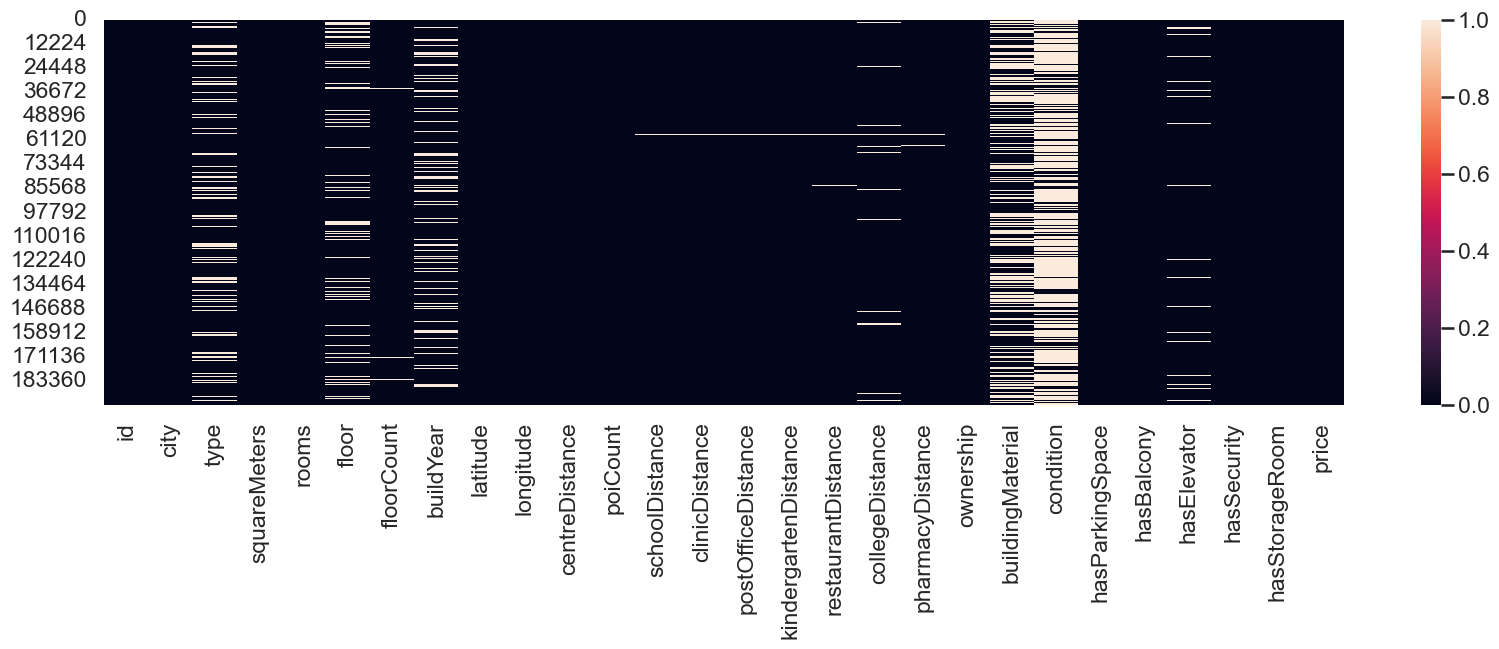

In [4]:
plt.figure(figsize=(20, 5))
sns.heatmap(df.isnull())

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195568 entries, 0 to 195567
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    195568 non-null  str    
 1   city                  195568 non-null  str    
 2   type                  153307 non-null  str    
 3   squareMeters          195568 non-null  float64
 4   rooms                 195568 non-null  float64
 5   floor                 160974 non-null  float64
 6   floorCount            193185 non-null  float64
 7   buildYear             163352 non-null  float64
 8   latitude              195568 non-null  float64
 9   longitude             195568 non-null  float64
 10  centreDistance        195568 non-null  float64
 11  poiCount              195568 non-null  float64
 12  schoolDistance        195400 non-null  float64
 13  clinicDistance        194840 non-null  float64
 14  postOfficeDistance    195320 non-null  float64
 15  kindergarte

In [6]:
df.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,195568.00,195568.00,160974.00,193185.00,163352.00,195568.00,195568.00,195568.00,195568.00,195400.00,194840.00,195320.00,195361.00,195089.00,190132.00,195291.00,195568.00
mean,58.70,2.68,3.33,5.31,1985.98,52.03,19.47,4.35,20.67,0.41,0.97,0.52,0.37,0.35,1.44,0.36,784183.30
std,21.41,0.92,2.53,3.31,33.81,1.34,1.78,2.84,24.33,0.46,0.89,0.50,0.44,0.46,1.10,0.46,409709.23
min,25.00,1.00,1.00,1.00,1850.00,49.98,14.45,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,150000.00
25%,44.00,2.00,2.00,3.00,1967.00,51.11,18.52,2.01,7.00,0.18,0.36,0.24,0.16,0.11,0.58,0.14,520000.00
50%,54.60,3.00,3.00,4.00,1994.00,52.19,19.90,3.98,14.00,0.29,0.68,0.39,0.26,0.23,1.12,0.24,699000.00
75%,68.55,3.00,4.00,6.00,2016.00,52.41,20.99,6.15,24.00,0.47,1.24,0.62,0.42,0.41,2.06,0.41,930000.00
max,150.00,6.00,29.00,29.00,2024.00,54.61,23.21,16.94,212.00,4.95,5.00,4.97,4.96,4.99,5.00,4.99,3250000.00


Sprawdzenie jak procentowo wygląda ilość ogłoszeń w 5 miastach najczęściej występujących w ogłoszeniach.

In [7]:
percentages = df['city'].value_counts(normalize=True).mul(100).round(2)
top_5 = percentages.head(5).copy()
top_5.loc['SUMA'] = top_5.sum()
top_5

city
warszawa   30.29
krakow     14.84
wroclaw    10.33
gdansk      9.82
lodz        7.82
SUMA       73.10
Name: proportion, dtype: float64

Jak widać 5 miast z największą liczbą ogłoszeń to aż 73% wszystkich ogłoszeń, jest to o tyle istotne, że jeśli chcemy patrzeć na dane "globalnie" dla całej polski należy mieć na uwadze że dane takie jak średnia wartość mogą być mocno zakłamane, dlatego w dalszej części skupie się konkretnie na Warszawie, tak by nie wprowadzać w błąd.

### Podsumowanie sprawdzenia danych  
Dane wydają się być wiarygodne, nie zawierają znaczących braków w istotnych kolumnach, nie zauważyłem sztucznie uzupełnionych kolumn wartościami w stylu 0/unknown itd.

### Usuwanie śmieci

Usuwam kolumnę id która nie bedzie potrzebna

In [8]:
df = df.drop('id',axis=1)

In [9]:
df = df[df['city'] == 'warszawa'].copy().reset_index(drop=True)

dodanie kolumny z wartością metra kwadratowego.

In [10]:
df['price_for_meter'] = df['price'] / df['squareMeters']

# Analiza danych

Tworzę tabele ze średnimi i medianami ceny, metrów oraz ciekawych miejsc/punktów z podziałem na rodzaj budownictwa.
Na potrzeby poniższego wykresu usuwam wiersze gdzie nie ma podanego roku budowy. Stanowią około 10% całości.

In [11]:

df_new = df.dropna(subset=['buildYear']).copy()
df_new['period'] = np.where(df_new['buildYear'] < 2010, 'Przed 2010', 'Od 2010')

table_1 = df_new.groupby(['type', 'period']).size().to_frame()
table_1.columns = pd.MultiIndex.from_tuples([('count', '')])

table_2 = df_new.pivot_table(values=['price', 'squareMeters', 'poiCount', 'price_for_meter'], index=['type', 'period'], aggfunc=['mean', 'median'])

result = table_2.join(table_1).reindex(columns=[('count', ''), ('mean', 'price'), ('median', 'price'),
('mean', 'squareMeters'), ('median', 'squareMeters'), ('mean', 'poiCount'), ('median', 'poiCount'),
('mean', 'price_for_meter'), ('median', 'price_for_meter')])
result

count       mean     median         mean  \
                                         price      price squareMeters   
type              period                                                 
apartmentBuilding Od 2010      8458 1178902.11 1080000.00        61.32   
                  Przed 2010   3576 1386809.81 1299000.00        78.18   
blockOfFlats      Od 2010      4986  980033.27  893000.00        57.78   
                  Przed 2010  18741  857996.40  789000.00        56.21   
tenement          Przed 2010   6420 1215139.52 1050000.00        60.90   

                                   median     mean   median            mean  \
                             squareMeters poiCount poiCount price_for_meter   
type              period                                                      
apartmentBuilding Od 2010           58.09    15.37    13.00        19377.20   
                  Przed 2010        74.93    24.04    18.00        18008.00   
blockOfFlats      Od 2010           55.75    11.61    10.00        17168.50   
                  Przed 2010        53.00    22.46    17.00        15694.84   
tenement          Przed 2010        55.00    42.70    32.00        19932.78   

                                      median  
                             price_for_meter  
type              period                      
apartmentBuilding Od 2010           18984.00  
                  Przed 2010        17658.77  
blockOfFlats      Od 2010           16811.59  
                  Przed 2010        15209.40  
tenement          Przed 2010        19543.24

Na powyższej tabeli możemy zobaczyć kilka rzeczy. Po pierwsze zgodnie z przewidywaniami kamienice budowane były w centrach miast, a cała infrastruktura otaczała je wraz z rozwojem co przejawia się prawie 2-krotnością interesujących punktów w okolicy względem budynków sprzed 2010 oraz niemalże 4-krotnością z nowszymi budynkami. Warto zwrócić uwagę na różnicę liczby ciekawych punktów między starszymi a nowszymi budynkami. Tak duża różnica może wynikać z tworzenia dużych zamkniętych osiedli tgz "sypialni" oddalonych od gęstszej zabudowy. Kolejną rzeczą na którą należy zwrócić uwagę jest spadek wielkości budowanych mieszkań. Znaczący spadek mediany w nowych apartametowcach świadczy dodatkowo o zalewaniu rynku mieszkaniami o małej wielkości. Można doszukiwać się przyczyn w demografii, jednak duże znaczenie może mieć też bardzo wysoka cena nowych mieszkań. Temat cen i ich konsekwencji rozwinę w dalszej części.  

Tworze wykresł słupkowy przedstawiajacy wartość nieruchomości oraz ilość ważnych punktów względem rodzaju nieruchomości

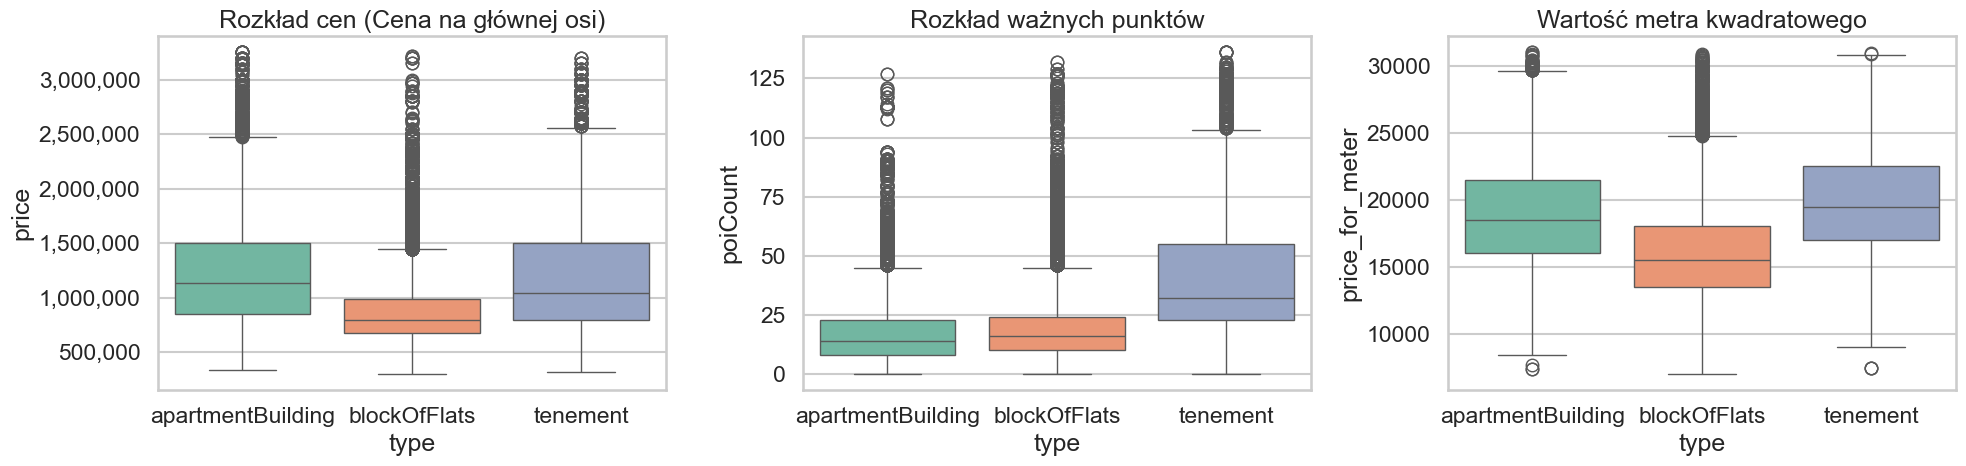

In [48]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df, x='type', y='price', palette='Set2', ax=ax1)
ax1.set_title('Rozkład cen (Cena na głównej osi)')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

sns.boxplot(data=df, x='type', y='poiCount', palette='Set2', ax=ax2)
ax2.set_title('Rozkład ważnych punktów')
plt.tight_layout() 

sns.boxplot(data=df, x='type', y='price_for_meter', palette='Set2', ax=ax3)
ax3.set_title('Wartość metra kwadratowego')
plt.tight_layout() 
plt.show()

W pierwszej kolejności w oczy rzuca się duża ilość wartości odstających na każdym z 3 wykresów. Zauważamy prawoskośność w całkowitych wartościach mieszkań, oraz dość symetryczne wartości przy cenie metra kwadratowego. Duża ilość wartości odstających wraz z prawoskośnością może powodować mocne zakłamanie wartości średnich. Należy brać to pod uwagę, szczególnie gdy w większości wypadków media straszą nas właśnie wartościami średnimi.

Przeanalizujmy teraz kolejno wszystkie wykresy. Na pierwszym widzimy, że pomimo iż mediana jest w okolicy miliona złotych, to zdecydowana prawoskośność oraz spora liczba wartości odstających mocno zaburza prawdziwy obraz sytuacji. Ciekawy jest bardzo podobny kształt wykresu zarówno dla kamienic, jak i dla apartamentów. Rozkłady ich cen są bardzo zbliżone, jednak każdy zdaje sobie sprawę, że wynika to z powodów biegunowo od siebie odległych. Bloki natomiast, mówiąc żartobliwie, "łączą wszystkie wady apartamentowców, ale za to nie mają żadnych zalet kamienic", przez co cenowo lądują na dole stawki.

Drugi wykres to spojrzenie na ważne punkty w okolicy (POI) z innej perspektywy niż zrobiliśmy to wyżej. Zgodnie z wnioskami z tabeli, kamienice budowane były dawno temu w okolicach centrum, więc ich wyniki są znacznie wyższe. Należy jednak zauważyć dużą liczbę wartości odstających dla bloków i apartamentowców – są to często nowe osiedla wybudowane tuż obok wielkiego centrum handlowego lub jakiejś galerii. Fakt galerii blisko takiej "sypialni" mocno podnosi średnią ilość POI dla tego konkretnego osiedla, jednak zaburza to obraz rzeczywistości. Jeśli jedyne ciekawe miejsce w okolicy to galeria handlowa, nie jest to ciekawa okolica.

Ostatnim wykresem jest wartość za metr kwadratowy. Mimo że mediany we wszystkich typach trzymają się mniej więcej podobnego poziomu, a całość wygląda dość symetrycznie, należy zwrócić uwagę na szeroką rozpiętość i sporą liczbę wartości odstających. Od boomu budowlanego lat 70. i 80. minęło już pół wieku. W wielu przypadkach niższe ceny bloków czy kamienic nie są żadną "okazją", lecz oznaczają po prostu mieszkanie-ruinę, w której żyły osoby starsze, a po ich śmierci rodzina szybko sprzedaje lokal wymagający kapitalnego remontu. Z drugiej strony niska cena za metr może oznaczać osiedle deweloperskie postawione bardzo daleko od centrum, ze słabą komunikacją i infrastrukturą.


Tworzę graf przedstwiający zestaw wykresów

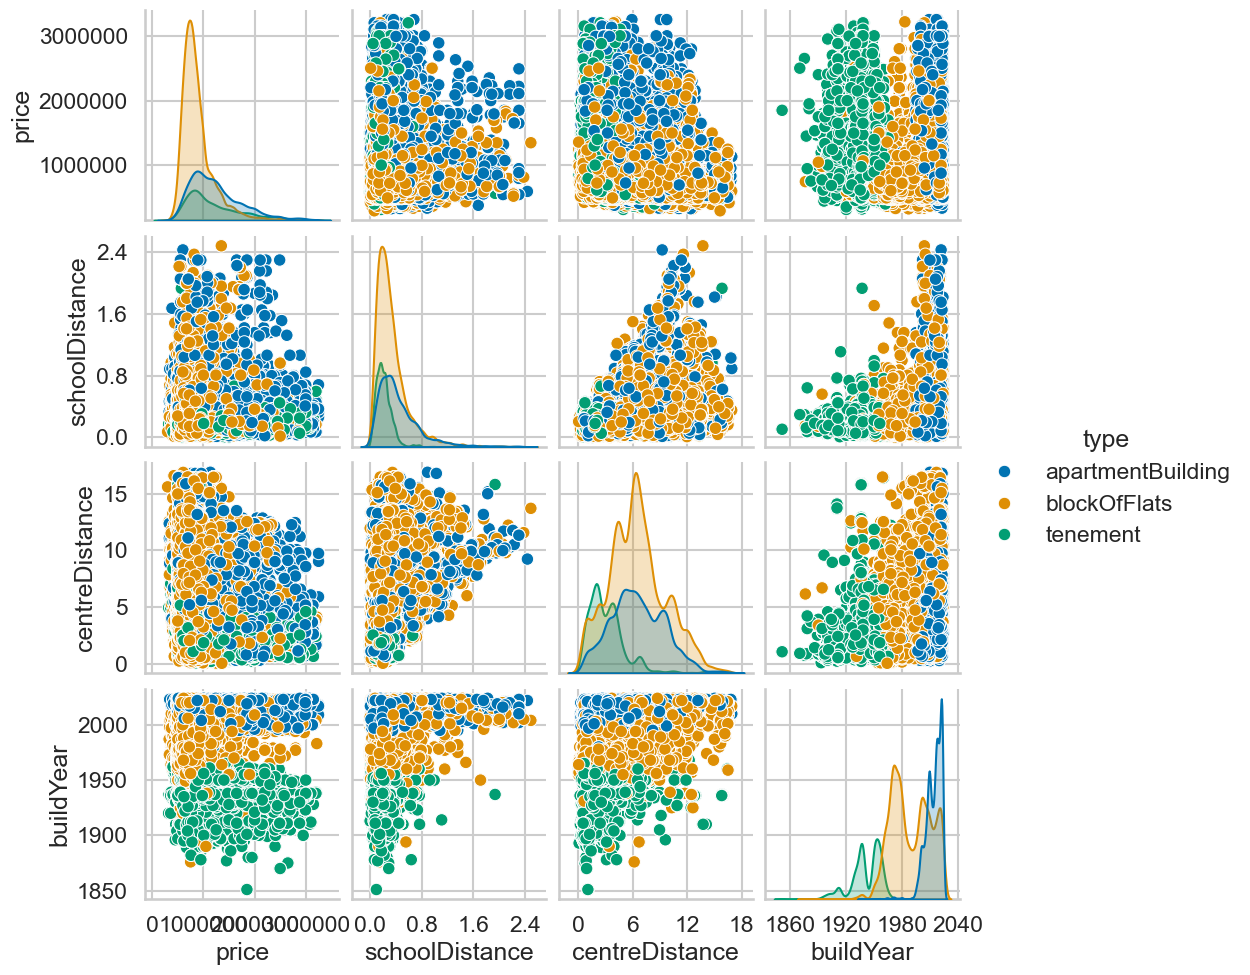

In [13]:
graf = sns.pairplot(df, vars=['price', 'schoolDistance', 'centreDistance','buildYear'],hue='type')
for ax in graf.axes.flatten():
    # Zwiększa liczbę wartości pokazanych na osi Y (nbins=8 oznacza około 8-10 wartości na osi)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    
    # Możesz też od razu zwiększyć liczbę wartości na osi X, jeśli chcesz
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
plt.show()

Zanim przejdę do cen mieszkań, chciałbym przedstawić jeszcze kilka ciekawych wniosków. Zacznijmy od anomalii odległości od centrum dla mieszkań z lat 70-80. Wydawać by się mogło, że Warszawa wybudowała nagle wielką liczbę mieszkań daleko od centrum, jednak ten skok spowodowany był w dużej mierze wchłonięciem ościennych miejscowości do obszaru Warszawy, które miało miejsce właśnie w tamtym okresie.

Bardzo ciekawe wnioski możemy też wynieść z odległości do szkoły. Zauważmy, że do lat 90. większość bloków budowano w odległości maksymalnie około 800 metrów od placówki. Natomiast po roku 2000 odległości w nowo budowanych inwestycjach rozciągnęły się równomiernie aż do około 2,5 km. Jest to 3-krotny wzrost w przeciągu zaledwie 10 lat. Oznacza to, że pomimo "szpetoty" zabudowy komunistycznej, trzeba im oddać, że planowanie przestrzenne mieli na dużo wyższym poziomie niż dzisiaj. Osiedla z wielkiej płyty budowano tak, by ludziom żyło się lepiej, a dzieci mogły iść do szkoły na piechotę czy pojechać rowerem. W porównaniu do dzisiejszych osiedli-sypialni, które często nie mają nawet dobrej komunikacji miejskiej, to przepaść.

Jednocześnie "chmura" punktów na wykresie ceny względem odległości do szkoły (brak widocznego korelacji) świadczy o tym, że aktualnie bliskość placówki nie ma dla kupujących większego znaczenia. Fakt ten jest kolejnym dobitnym dowodem na bardzo słabą demografię kupujących. Od biedy z jednym dzieckiem któryś z rodziców może podjechać autem do szkoły, ale wożenie codziennie 2 czy 3 to już byłby duży problem – a skoro tak to albo kupujących dzieci nie ma i nie chce mieć, albo nie planuje większej rodziny.




Tworzę mapę z naniesionymi na nią ofertami w budynkach wybudowanych po 1970 roku.

In [14]:

city_growth = df[df['buildYear'] > 1970].dropna(subset=['latitude', 'longitude'])
mapa = px.scatter_mapbox(
    city_growth, 
    lat="latitude",     
    lon="longitude",    
    color="type",         
    hover_name="type",  
    hover_data=["buildYear", "price", "price_for_meter" ], 
    color_discrete_map={
        'tenement': 'crimson',             
        'apartmentBuilding': 'royalblue',    
        'blockOfFlats': 'darkorange' 
    },
    size_max=20, 
    zoom=10.5,            
    mapbox_style="open-street-map"
)
mapa.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
mapa.show()

Powiedzenie „obraz wart jest tysiąca słów” kolejny raz potwierdza swoją słuszność. Po pierwsze widać tu zwartą zabudowę bloków w sporym oddaleniu od centrum, są to właśnie te PRL-owskie miasteczka które zostały wchłonięte przez warszawę. Widać również nowe apartamentowce wciśnięte wszędzie tam, gdzie było jeszcze miejsce. Jest to dowód na aktualą i przysłowiową wręcz betonozę Warszawy, gdzie parki, skwery, a nawet zwykłe dawne nieużytki – wszystko to zalewane jest betonem. Kolejną rzeczą której nie da się łatwo przedstawić w liczbach jest ewentualna przyszłość rozbudowy. Z mapy można wnioskować żę w dłuższej perspektywie dominującym kierunkiem rozbudowy będzie południowy zachód. Z pozostałych stron miasto jest otoczone dużymi połaciami leśnymi, których przekształcenie w tereny zabudowane jest dziś praktycznie niemożliwe ze względu na ochronę przyrody, status parków krajobrazowych i narodowych oraz aktualne nastawienie społeczne i polityczne do wycinki lasów. Warto zauważyć jak lotnisko Chopina "wcina" się w krąg zabudowy wokół Warszawy, teren lotniska mrozi w strukturze miasta bardzo dużą ilość gruntów.

## Analiza zdolnosci kredytowej dla przeciętnego Polaka

W tej części spróbuje odpoweiedzieć na co może liczyć w kwesti mieszkania przeciętny pracownik, lub para żyjąca w Warszawie przy założeniu że mediana zarobków na osobę wynosiła w maju 2024  6480 zł brutto "https://stat.gov.pl/files/gfx/portalinformacyjny/pl/defaultaktualnosci/5474/32/5/1/rozklad_wynagrodzen_w_gospodarce_narodowej_w_maju_2024_r..pdf" Założyłem też "optymistyczny" przelicznik brutto -- netto w wysokości 77%.

W celu ukazania skali problemu oraz barier wejścia na rynek, zastosowałem uproszczony model zdolności kredytowej. Model zakłada koszty utrzymania osoby dorosłej na 1500zł  oraz bezpieczny wskaźnik DTI wynoszący 45%. Przyjęty mnożnik wartości mieszkania 140k kredytu na każde 1k raty odpowiada rynkowym warunkom kredytowania na 25 lat w roku 2024. Uwzględniony został również wkład własny w wysokości 20% wartości mieszkania.

definicja funkcji pomocniczej obliczającej maksymalną zdolność kredytową dla zarobków wynosząćych uwczesną medianę.

In [39]:
median_net_earnings = 6480 * 0.77
def max_price(x):
    
    earnings = median_net_earnings * x
    costs = x * 1500
    
    max_monthly_payment = (earnings - costs) * 0.45
    max_loan = (max_monthly_payment / 1000) * 140000
    max_price = max_loan / 0.80
    
    return max_price
single = max_price(1)
couple = max_price(2)

Definicja funkcji pomocniczej drukującej "etykiety" nad kolumnami

In [40]:
def add_labels(bars, totals):
    for bar, total_value in zip(bars, totals):
        height = bar.get_height()
        percent = (height / total_value) * 100
        
        ax.annotate(f'{int(height)} ({percent:.1f}%)',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

Tworzenie wykresu przedstawiającego finansowe możliwości singla/pary

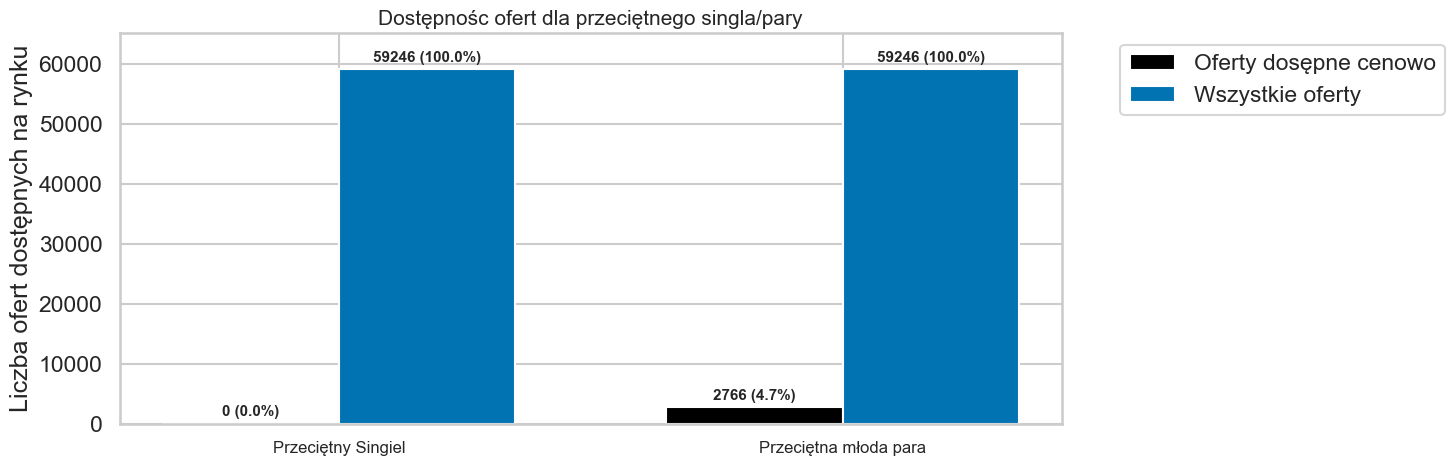

In [41]:
single_available = len(df[df['price'] <= single]) 
couple_available = len(df[df['price'] <= couple])    
total_offers = len(df)  


categories = ['Przeciętny Singiel', 'Przeciętna młoda para']
available_counts = [single_available, couple_available]
total_counts = [total_offers, total_offers]

x_indexes = np.arange(2)
bar_width = 0.35

fig, ax = plt.subplots(figsize=(15, 5))

bar_available = ax.bar(x_indexes - bar_width/2, available_counts, bar_width, label='Oferty dosępne cenowo', color='black')
bar_total = ax.bar(x_indexes + bar_width/2, total_counts, bar_width, label='Wszystkie oferty')

ax.set_title('Dostępnośc ofert dla przeciętnego singla/pary', fontsize=15)
ax.set_ylabel('Liczba ofert dostępnych na rynku')
ax.set_xticks(x_indexes)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, max(total_counts) * 1.1)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')



add_labels(bar_available, total_counts)
add_labels(bar_total, total_counts) 

plt.tight_layout()
plt.show()

Powyższy wykres dobitnie przedstawia jak bardzo rynek nieruchomości w Warszawie "uciekł" "przeciętnemu" Polakowi. Zdolność kredytowa przeciętnie zarabiającego Polaka posiadającego 20% wkładu i biorącego kredyt na 25 lat nie pozwalała mu na zakup nawet najtańszego mieszkania. Pary mogą liczyć na około 5% ofert, należy pamiętać jednak że znaczna część tych ofert może dotyczyć mieszkań niezdatnych do życia bez generalnego remontu. 

Funkcja pomocnicza obliczająca ile trzeba zarabiać by móc kupić na 25 - letni kredyt, mieszkanie o wartości mediany wszystkich ofert.

In [42]:
median_price = df['price'].median()
def required_salary(target_price, adults_count):

    required_loan = target_price * 0.80
    required_installment = (required_loan / 140000) * 1000
    
    free_cash = required_installment / 0.45
    living_costs = adults_count * 1500
    total_net_salary = free_cash + living_costs
    total_gross_salary = total_net_salary / 0.77
    return total_gross_salary





In [43]:
single_gross_salary = required_salary(median_price, adults_count=1)
couple_gross_salary = required_salary(median_price, adults_count=2)
print(f"singiel chcący kupić mieszkanie w wartości wynoszącej mediane wszystkich ofert musi zarabiać : {single_gross_salary:,.0f} zł brutto")
print(f"Para chcący kupić mieszkanie w wartości wynoszącej mediane wszystkich ofert musi zarabiać łącznie : {couple_gross_salary:,.0f} zł brutto.")

singiel chcący kupić mieszkanie w wartości wynoszącej mediane wszystkich ofert musi zarabiać : 16,543 zł brutto
Para chcący kupić mieszkanie w wartości wynoszącej mediane wszystkich ofert musi zarabiać łącznie : 18,491 zł brutto.


Zgodnie z obliczeniami, będąc singlem należało by znaleźć się w top 5-10% najlepiej zarabiających Polaków by móc dostać kredyt na średniej wartości mieszkanie w Warszawie. W przypadku pary każda z osób musiała by znajdować się w 25% najlepiej zarabiających polaków.

Na koniec przedstawie jakie teoretycznie paramtery ma "średnie" mieszkanie 

In [44]:
df.describe().loc['50%']


squareMeters               55.10
rooms                       3.00
floor                       3.00
floorCount                  5.00
buildYear                1999.00
latitude                   52.23
longitude                  21.01
centreDistance              5.85
poiCount                   16.00
schoolDistance              0.28
clinicDistance              0.52
postOfficeDistance          0.42
kindergartenDistance        0.23
restaurantDistance          0.18
collegeDistance             1.16
pharmacyDistance            0.23
price                  885000.00
price_for_meter         16899.91
Name: 50%, dtype: float64

# podsumowanie

Mówiąc wprost: rynek nieruchomości w Warszawie całkowicie odleciał.  
Rozwijając to podsumowanie, warto zwrócić uwagę na kilka rzeczy. Warszawa dynamicznie się rozwija i przyciąga młodych ludzi z całej Polski, ale jednocześnie praktycznie uniemożliwia im kupno mieszkania bez dużej pomocy rodziców lub rodziny.  
Nowe mieszkania, mimo że są często gorzej zlokalizowane, mają słabsze otoczenie i większą odległość od centrum, są kompletnie poza zasięgiem przeciętnie zarabiającego singla, a nawet pary.  
Jedną z odpowiedzi rynku na tę sytuację jest wyraźny spadek mediany powierzchni mieszkań budowanych po 2010 roku. Skoro młodych nie stać na normalne metraże, deweloperzy zaczęli masowo budować coraz mniejsze lokale.  
To z kolei może tłumaczyć brak korelacji między ceną mieszkania a odległością do szkoły – jeśli i tak nie stać Cię na większe mieszkanie, planowanie rodziny schodzi na dalszy plan